In [1]:
!pip install -q git+https://github.com/probml/dynamax.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


2025-11-03 06:17:01.993910: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762150622.016198    4478 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762150622.022910    4478 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


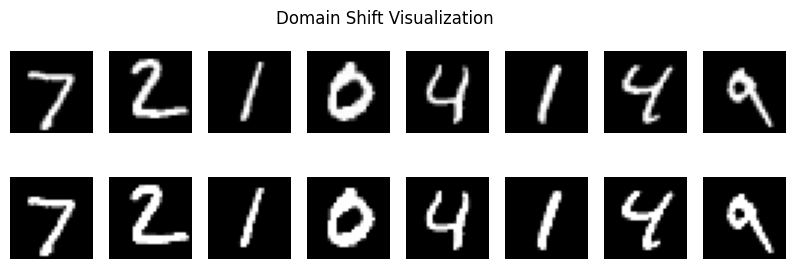

In [2]:
# =====================================
# 1. Setup and Data Preparation
# =====================================
import jax, jax.numpy as jnp
import optax, numpy as np, matplotlib.pyplot as plt, time
from flax import nnx
from tensorflow.keras.datasets import mnist
import copy

(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0
X_train = X_train.reshape(-1, 28, 28)
X_test  = X_test.reshape(-1, 28, 28)

# contrast and brightness shift
X_test_shifted = np.clip(((X_test - 0.5) * 1.8 + 0.5) + 0.4, 0, 1)
y_test_shifted = y_test

fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for i in range(8):
    axes[0, i].imshow(X_test[i], cmap="gray");       axes[0, i].axis("off")
    axes[1, i].imshow(X_test_shifted[i], cmap="gray");axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original", rotation=0, labelpad=40)
axes[1, 0].set_ylabel("Shifted", rotation=0, labelpad=40)
plt.suptitle("Domain Shift Visualization")
plt.show()

In [3]:
# =====================================
# 2. Define Two-Layer RNN Model (NNX)
# =====================================
class TwoLayerRNN(nnx.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout_rate=0.1, *, rngs: nnx.Rngs):
        self.hidden_size = hidden_dim

        # Layer 1
        self.Wxh1 = nnx.Linear(input_dim, hidden_dim, rngs=rngs)
        self.Whh1 = nnx.Linear(hidden_dim, hidden_dim, rngs=rngs)

        # Layer 2
        self.Wxh2 = nnx.Linear(hidden_dim, hidden_dim, rngs=rngs)
        self.Whh2 = nnx.Linear(hidden_dim, hidden_dim, rngs=rngs)

        # Fully connected classifier head
        self.fc = nnx.Linear(hidden_dim, num_classes, rngs=rngs)

        # Dropout for regularization
        self.dropout = nnx.Dropout(dropout_rate, rngs=rngs)

    def __call__(self, x, h1, h2, *, is_training=True):
        # x: (batch, seq, feat)
        for t in range(x.shape[1]):
            # First RNN layer
            h1 = jnp.tanh(self.Wxh1(x[:, t, :]) + self.Whh1(h1))
            if is_training:
                h1 = self.dropout(h1)

            # Second RNN layer
            h2 = jnp.tanh(self.Wxh2(h1) + self.Whh2(h2))
            if is_training:
                h2 = self.dropout(h2)

        # Use final h2 as feature vector
        logits = self.fc(h2)
        return logits


In [4]:
# =====================================
# 3. Loss, Accuracy, and Utility
# =====================================
def cross_entropy(logits, labels):
    y = jax.nn.one_hot(labels, 10)
    return -jnp.mean(jnp.sum(y * jax.nn.log_softmax(logits), axis=-1))

def accuracy(logits, labels):
    return jnp.mean(jnp.argmax(logits, -1) == labels)

# =====================================
# Utility: Evaluate batch (for TwoLayerRNN)
# =====================================
def eval_batch(model, x, y):
    # Initialize hidden states for both RNN layers
    h1 = jnp.zeros((x.shape[0], model.hidden_size))
    h2 = jnp.zeros_like(h1)

    # Forward pass (disable dropout)
    logits = model(x, h1, h2, is_training=False)

    return cross_entropy(logits, y), accuracy(logits, y)


In [5]:
# =====================================
# 4. Baseline Training (Two-Layer RNN)
# =====================================
rngs = nnx.Rngs(0)
model = TwoLayerRNN(28, 32, 10, rngs=rngs) 
optimizer = nnx.Optimizer(model, optax.adam(2e-3))

epochs = 30
batch_size = 256  # reduce slightly for stability
train_losses, test_accs = [], []

print("\nTraining baseline 2-layer RNN...")
for ep in range(epochs):
    idx = np.random.choice(len(X_train), batch_size, replace=False)
    Xb, yb = X_train[idx], y_train[idx]

    def loss_fn(model):
        h1 = jnp.zeros((Xb.shape[0], model.hidden_size))
        h2 = jnp.zeros_like(h1)
        logits = model(Xb, h1, h2, is_training=True)
        loss = cross_entropy(logits, yb)
        return loss, logits

    (loss_value, _), grads = nnx.value_and_grad(loss_fn, has_aux=True)(model)
    optimizer.update(grads)

    if (ep + 1) % 2 == 0 or ep == 0:
        h1 = jnp.zeros((X_test.shape[0], model.hidden_size))
        h2 = jnp.zeros_like(h1)
        logits = model(X_test, h1, h2, is_training=False)
        l = cross_entropy(logits, y_test)
        a = jnp.mean(jnp.argmax(logits, -1) == y_test)
        train_losses.append(float(loss_value))
        test_accs.append(float(a))
        print(f"Epoch {ep+1}/{epochs}: train_loss={float(loss_value):.4f} test_acc={float(a):.4f}")

baseline_model = copy.deepcopy(model)
h1 = jnp.zeros((X_test_shifted.shape[0], model.hidden_size))
h2 = jnp.zeros_like(h1)
logits = model(X_test_shifted, h1, h2, is_training=False)
l_shift = cross_entropy(logits, y_test_shifted)
a_shift = jnp.mean(jnp.argmax(logits, -1) == y_test_shifted)
print(f"Baseline accuracy (orig): {test_accs[-1]:.4f}")
print(f"Baseline accuracy (shifted): {a_shift:.4f}")

INFO:2025-11-03 06:17:05,927:jax._src.xla_bridge:924: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-11-03 06:17:05,929:jax._src.xla_bridge:924: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory



Training baseline 2-layer RNN...
Epoch 1/30: train_loss=2.3237 test_acc=0.1556
Epoch 2/30: train_loss=2.3015 test_acc=0.1907
Epoch 4/30: train_loss=2.2367 test_acc=0.2492
Epoch 6/30: train_loss=2.1840 test_acc=0.2796
Epoch 8/30: train_loss=2.1446 test_acc=0.2986
Epoch 10/30: train_loss=2.1008 test_acc=0.3322
Epoch 12/30: train_loss=2.0353 test_acc=0.3417
Epoch 14/30: train_loss=2.0634 test_acc=0.3507
Epoch 16/30: train_loss=1.9881 test_acc=0.3715
Epoch 18/30: train_loss=1.8928 test_acc=0.3834
Epoch 20/30: train_loss=1.8669 test_acc=0.4042
Epoch 22/30: train_loss=1.8621 test_acc=0.4170
Epoch 24/30: train_loss=1.7678 test_acc=0.4223
Epoch 26/30: train_loss=1.8467 test_acc=0.4332
Epoch 28/30: train_loss=1.7440 test_acc=0.4410
Epoch 30/30: train_loss=1.6954 test_acc=0.4486
Baseline accuracy (orig): 0.4486
Baseline accuracy (shifted): 0.4406


In [6]:
# =====================================
# 5. Selective Adaptation (FC layer only)
# =====================================
selective_model = copy.deepcopy(baseline_model)
sel_opt = nnx.Optimizer(selective_model.fc, optax.adam(1e-3))
sel_losses, sel_accs = [], []
num_adapt_epochs = 10

print("\nSelective adaptation (fc layer only)...")

for ep in range(num_adapt_epochs):
    Xb, yb = X_test_shifted, y_test_shifted

    def loss_fn(fc):
        h1 = jnp.zeros((Xb.shape[0], selective_model.hidden_size))
        h2 = jnp.zeros_like(h1)

        # Forward pass through both recurrent layers (frozen)
        for t in range(Xb.shape[1]):
            h1 = jnp.tanh(selective_model.Wxh1(Xb[:, t, :]) + selective_model.Whh1(h1))
            h2 = jnp.tanh(selective_model.Wxh2(h1) + selective_model.Whh2(h2))

        # Stop gradient from flowing into the recurrent layers
        h_final = jax.lax.stop_gradient(h2)

        # Compute logits via trainable fc layer
        logits = fc(h_final)
        loss = cross_entropy(logits, yb)
        return loss, logits

    (loss_value, _), grads = nnx.value_and_grad(loss_fn, has_aux=True)(selective_model.fc)
    sel_opt.update(grads)

    l, a = eval_batch(selective_model, X_test_shifted, y_test_shifted)
    sel_losses.append(float(l))
    sel_accs.append(float(a))
    print(f"Adapt Epoch {ep+1}/{num_adapt_epochs}: loss={float(l):.4f} acc={float(a):.4f}")


Selective adaptation (fc layer only)...
Adapt Epoch 1/10: loss=1.5906 acc=0.4431
Adapt Epoch 2/10: loss=1.5866 acc=0.4449
Adapt Epoch 3/10: loss=1.5827 acc=0.4462
Adapt Epoch 4/10: loss=1.5789 acc=0.4469
Adapt Epoch 5/10: loss=1.5752 acc=0.4491
Adapt Epoch 6/10: loss=1.5716 acc=0.4511
Adapt Epoch 7/10: loss=1.5681 acc=0.4534
Adapt Epoch 8/10: loss=1.5646 acc=0.4551
Adapt Epoch 9/10: loss=1.5612 acc=0.4568
Adapt Epoch 10/10: loss=1.5578 acc=0.4590


In [7]:
# =====================================
# 6. EKF Adaptation (Memory-Safe via CMGF for TwoLayerRNN)
# =====================================
from jax.flatten_util import ravel_pytree
from dynamax.generalized_gaussian_ssm.models import ParamsGGSSM
from dynamax.generalized_gaussian_ssm.inference import conditional_moments_gaussian_filter, EKFIntegrals

print("\nEKF-based adaptation (Memory-Safe via CMGF)...")

ekf_model = copy.deepcopy(baseline_model)
fc = ekf_model.fc

# Flatten FC parameters
fc_params = nnx.state(fc)
flat_params, unflatten_fn = ravel_pytree(fc_params)
state_dim = flat_params.size
print(f"FC layer parameters: {state_dim}")

# Define prior and noise
prior_mean = flat_params
prior_cov = jnp.eye(state_dim) * 0.1
Q = jnp.eye(state_dim) * 1e-4
R = jnp.eye(10) * 0.05

# Define transition and emission functions
def f_fn(w, u=None):
    return w  # static weights

def emission_mean_fn(w, x):
    params = unflatten_fn(w)
    W = params['kernel'].value
    b = params['bias'].value
    logits = jnp.dot(x, W) + b
    return jax.nn.softmax(logits)

def emission_cov_fn(w, x):
    p = emission_mean_fn(w, x)
    return jnp.diag(p * (1 - p)) + 1e-5 * jnp.eye(10)

params = ParamsGGSSM(
    initial_mean=prior_mean,
    initial_covariance=prior_cov,
    dynamics_function=f_fn,
    dynamics_covariance=Q,
    emission_mean_function=emission_mean_fn,
    emission_cov_function=emission_cov_fn
)

ekf_losses, ekf_accs = [], []

num_adapt_epochs = 10

for ep in range(num_adapt_epochs):
    print(f"\nEKF Epoch {ep+1}/{num_adapt_epochs}")

    # 🔹 Compute hidden states through both RNN layers (frozen)
    h1 = jnp.zeros((X_test_shifted.shape[0], ekf_model.hidden_size))
    h2 = jnp.zeros_like(h1)
    for t in range(X_test_shifted.shape[1]):
        h1 = jnp.tanh(ekf_model.Wxh1(X_test_shifted[:, t, :]) + ekf_model.Whh1(h1))
        h2 = jnp.tanh(ekf_model.Wxh2(h1) + ekf_model.Whh2(h2))

    features = h2  # final hidden representation
    y_onehot = jax.nn.one_hot(y_test_shifted, 10)

    # 🔹 Run CMGF (Extended Kalman Filter)
    posterior = conditional_moments_gaussian_filter(
        params,
        EKFIntegrals(),
        y_onehot,
        inputs=features
    )

    # Update model weights
    final_params = unflatten_fn(posterior.filtered_means[-1])
    fc.kernel.value = final_params['kernel'].value
    fc.bias.value = final_params['bias'].value

    # Update EKF state for next iteration
    params = ParamsGGSSM(
        initial_mean=posterior.filtered_means[-1],
        initial_covariance=posterior.filtered_covariances[-1],
        dynamics_function=f_fn,
        dynamics_covariance=Q,
        emission_mean_function=emission_mean_fn,
        emission_cov_function=emission_cov_fn
    )

    # Evaluate on shifted data
    l, a = eval_batch(ekf_model, X_test_shifted, y_test_shifted)
    ekf_losses.append(float(l))
    ekf_accs.append(float(a))
    print(f"  loss={float(l):.4f} acc={float(a):.4f}")



EKF-based adaptation (Memory-Safe via CMGF)...
FC layer parameters: 330

EKF Epoch 1/10
  loss=1.2051 acc=0.5924

EKF Epoch 2/10
  loss=1.1917 acc=0.5978

EKF Epoch 3/10
  loss=1.1896 acc=0.5976

EKF Epoch 4/10
  loss=1.1895 acc=0.5987

EKF Epoch 5/10
  loss=1.1897 acc=0.5991

EKF Epoch 6/10
  loss=1.1900 acc=0.5995

EKF Epoch 7/10
  loss=1.1903 acc=0.5997

EKF Epoch 8/10
  loss=1.1905 acc=0.5999

EKF Epoch 9/10
  loss=1.1906 acc=0.5996

EKF Epoch 10/10
  loss=1.1908 acc=0.5995


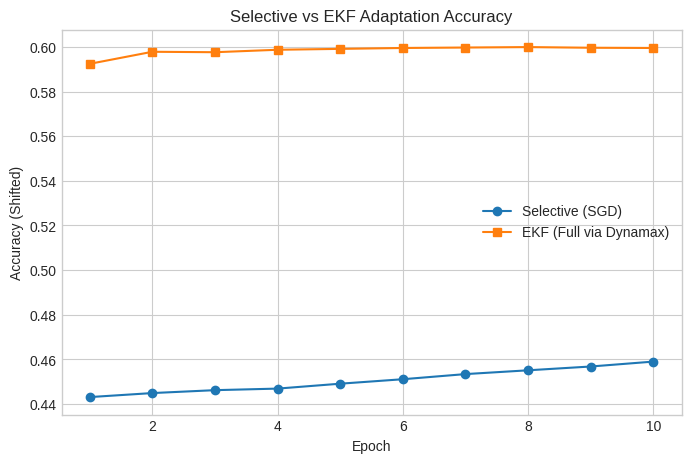

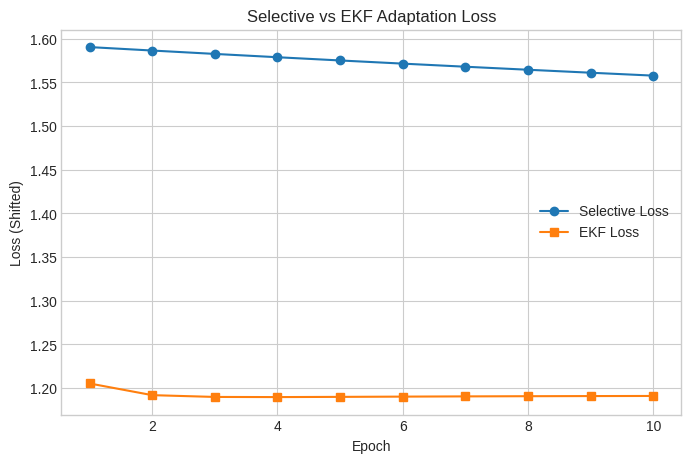

In [8]:
# =====================================
# 7. Visualizations
# =====================================
epochs_ = np.arange(1, num_adapt_epochs + 1)
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(8,5))
plt.plot(epochs_, sel_accs, "o-", label="Selective (SGD)")
plt.plot(epochs_, ekf_accs, "s-", label="EKF (Full via Dynamax)")
plt.xlabel("Epoch"); plt.ylabel("Accuracy (Shifted)")
plt.title("Selective vs EKF Adaptation Accuracy"); plt.legend(); plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs_, sel_losses, "o-", label="Selective Loss")
plt.plot(epochs_, ekf_losses, "s-", label="EKF Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss (Shifted)")
plt.title("Selective vs EKF Adaptation Loss"); plt.legend(); plt.show()

# Parameter change magnitude
def l2_diff(m1, m2):
    def flat_numeric_params(m):
        leaves, _ = jax.tree_util.tree_flatten(nnx.state(m))
        # keep only real numeric arrays
        return [jnp.asarray(x) for x in leaves if jnp.issubdtype(jnp.asarray(x).dtype, jnp.floating)]
    p1, p2 = flat_numeric_params(m1), flat_numeric_params(m2)
    return float(sum(jnp.linalg.norm(a - b) for a, b in zip(p1, p2)))


[Info] Detected 2-layer RNN for visualization.


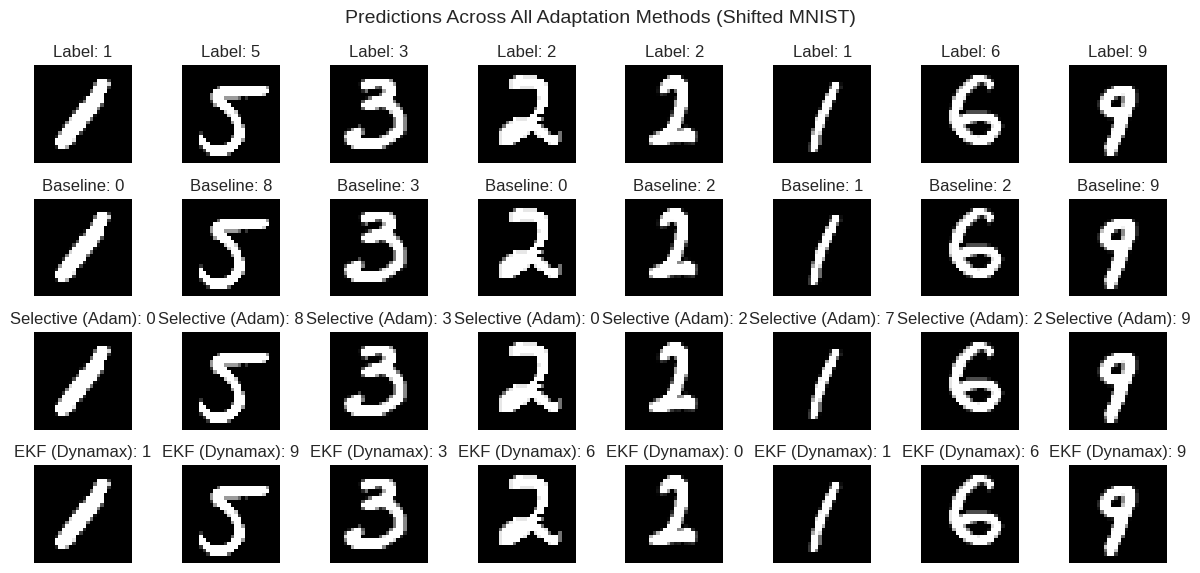

In [9]:
# =====================================
# 8. Multi-Model Prediction Visualization (Universal for L-Layer RNNs)
# =====================================
def visualize_all_models(models_dict, X, y, title="Model Comparison"):
    """
    models_dict: Ordered dictionary or dict-like object of {name: model}
    X, y: dataset
    title: figure title
    """
    import matplotlib.pyplot as plt

    idx = np.random.choice(len(X), 8, replace=False)
    Xs, ys = X[idx], y[idx]

    # Detect RNN depth (based on first model)
    first_model = list(models_dict.values())[0]
    layer_count = sum(hasattr(first_model, f"Whh{i+1}") for i in range(10))
    if layer_count == 0:
        layer_count = 1
    print(f"[Info] Detected {layer_count}-layer RNN for visualization.")

    # Generate predictions for all models
    predictions = {}
    for name, model in models_dict.items():
        hidden_states = [jnp.zeros((Xs.shape[0], model.hidden_size)) for _ in range(layer_count)]
        preds = jnp.argmax(model(Xs, *hidden_states), axis=-1)
        predictions[name] = preds

    # Create a grid: one row per model + one for ground truth
    n_models = len(models_dict)
    fig, axes = plt.subplots(n_models + 1, 8, figsize=(12, 2.8 + n_models))
    fig.suptitle(title, fontsize=14)

    # Plot images once in the top row
    for i in range(8):
        axes[0, i].imshow(Xs[i], cmap="gray")
        axes[0, i].set_title(f"Label: {ys[i]}")
        axes[0, i].axis("off")

    # Plot predictions for each model
    for row, (name, preds) in enumerate(predictions.items(), start=1):
        for i in range(8):
            axes[row, i].imshow(Xs[i], cmap="gray")
            axes[row, i].set_title(f"{name}: {int(preds[i])}")
            axes[row, i].axis("off")

    plt.tight_layout()
    plt.show()
visualize_all_models(
    {
        "Baseline": baseline_model,
        "Selective (Adam)": selective_model,
        "EKF (Dynamax)": ekf_model,
    },
    X_test_shifted,
    y_test_shifted,
    title="Predictions Across All Adaptation Methods (Shifted MNIST)"
)

In [10]:
# =====================================
# 9. Comprehensive Experiment Summary
# =====================================
import pandas as pd

print("\n" + "="*70)
print("COMPREHENSIVE SUMMARY")
print("="*70)

# Baseline metrics
baseline_orig_acc = test_accs[-1] if 'test_accs' in locals() else float('nan')
baseline_shift_acc = float(a_shift)

# Selective adaptation metrics
sel_final_acc = sel_accs[-1] if len(sel_accs) > 0 else float('nan')
sel_final_loss = sel_losses[-1] if len(sel_losses) > 0 else float('nan')

# EKF metrics
ekf_final_acc = ekf_accs[-1] if len(ekf_accs) > 0 else float('nan')
ekf_final_loss = ekf_losses[-1] if len(ekf_losses) > 0 else float('nan')

# Compute accuracy improvements
sel_improvement = sel_final_acc - baseline_shift_acc
ekf_improvement = ekf_final_acc - baseline_shift_acc

# Parameter statistics
num_params = fc.kernel.value.size + fc.bias.value.size
l2_sel = l2_diff(baseline_model, selective_model) if 'selective_model' in locals() else float('nan')
l2_ekf = l2_diff(baseline_model, ekf_model)

# Memory estimates
mem_ekf = num_params**2     # full covariance
mem_sel = 0                 # none

# Construct summary table
summary = pd.DataFrame({
    "Metric": [
        "Accuracy (original data)",
        "Accuracy (shifted - before)",
        "Accuracy (shifted - after)",
        "Accuracy improvement",
        "Final loss",
        "Trainable parameters",
        "Memory overhead (elements)",
        "Parameter L2 change"
    ],
    "Baseline": [
        baseline_orig_acc,
        baseline_shift_acc,
        "-",
        "-",
        "-",
        num_params,
        "-",
        "-"
    ],
    "Selective (Adam)": [
        "-",
        baseline_shift_acc,
        sel_final_acc,
        sel_improvement,
        sel_final_loss,
        num_params,
        mem_sel,
        l2_sel
    ],
    "EKF (Dynamax)": [
        "-",
        baseline_shift_acc,
        ekf_final_acc,
        ekf_improvement,
        ekf_final_loss,
        num_params,
        mem_ekf,
        l2_ekf
    ]
})

print(summary.to_string(index=False, float_format=lambda x: f"{x:0.4f}"))

print("\n" + "="*70 + "\n")


COMPREHENSIVE SUMMARY
                     Metric Baseline Selective (Adam) EKF (Dynamax)
   Accuracy (original data)   0.4486                -             -
Accuracy (shifted - before)   0.4406           0.4406        0.4406
 Accuracy (shifted - after)        -           0.4590        0.5995
       Accuracy improvement        -           0.0184        0.1589
                 Final loss        -           1.5578        1.1908
       Trainable parameters      330              330           330
 Memory overhead (elements)        -                0        108900
        Parameter L2 change        -           0.2046       58.7214


